# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [55]:
STUDENT_NAME = "Trần Bảo Ngọc"  # TODO: Họ và tên
STUDENT_ID = "2452838"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Trần Bảo Ngọc (2452838)


In [56]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /Users/yippe/Downloads/SummerCourse2026/week 2/numphy/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [57]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [58]:
# TODO N1
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [59]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [60]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])


In [61]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train - train_feature_mean)/train_feature_std
X_val_scaled = (X_val - train_feature_mean)/train_feature_std

In [62]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [63]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [64]:
# TODO N3
correct_mask = (true_labels == predicted_classes)
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = ~correct_mask & high_confidence_mask
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [65]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [66]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [67]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = raw_df.isnull().sum().sum()

## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [68]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [69]:
# TODO D2
df_clean = raw_df.copy()
df_clean = df_clean.replace('?', np.nan)
# for column in NUMERIC_COLUMNS:
#     ...
# missing_by_column = ...
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])

missing_by_column = df_clean.isnull().sum()

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [70]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [71]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.values
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / (auto_feature_std + 1e-8)

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [72]:
# TODO D4
price_index = AUTO_FEATURES.index('price')
price_z = (X_auto[:,price_index]-np.mean(X_auto[:,price_index]))/np.std(X_auto[:,price_index])
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df[price_outlier_mask]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [73]:
# TODO D5
engine_price_corr = np.corrcoef(X_auto[:,AUTO_FEATURES.index('engine_size')], X_auto[:,AUTO_FEATURES.index('price')])[0, 1]
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

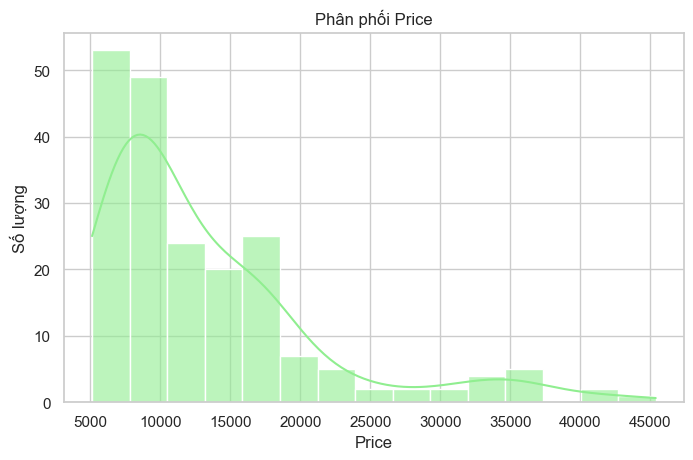

In [74]:
# TODO M2.1: histogram/KDE của price
plt.figure(figsize=(8, 4.8))
sns.histplot(data=df_clean, x='price', kde=True, color="lightgreen", alpha=0.6, bins=15)
plt.title("Phân phối Price")
plt.xlabel("Price")
plt.ylabel("Số lượng")
plt.grid(True)
plt.show()

**Nhận xét:** Phân phối chủ yếu tập trung ở khúc 5000-15000.

## M2.2 Dataset có cân bằng theo body style không?

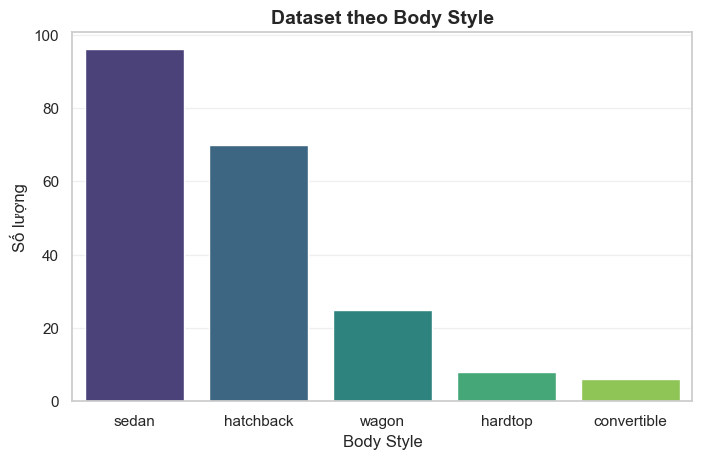

In [75]:
# TODO M2.2: countplot của body_style
plt.figure(figsize=(8, 4.8))
style_counts = df_clean['body_style'].value_counts()
sns.barplot(x=style_counts.index, y=style_counts.values, hue=style_counts.index, palette='viridis', legend=False)
plt.title('Dataset theo Body Style', fontsize=14, fontweight='bold')
plt.xlabel('Body Style', fontsize=12)
plt.ylabel('Số lượng', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.show()


**Nhận xét:** Phân phối theo Body Style không đều. Hầu hết tập trung vào sedan, hatchback và wagon.

## M2.3 Price khác nhau theo body style ra sao?

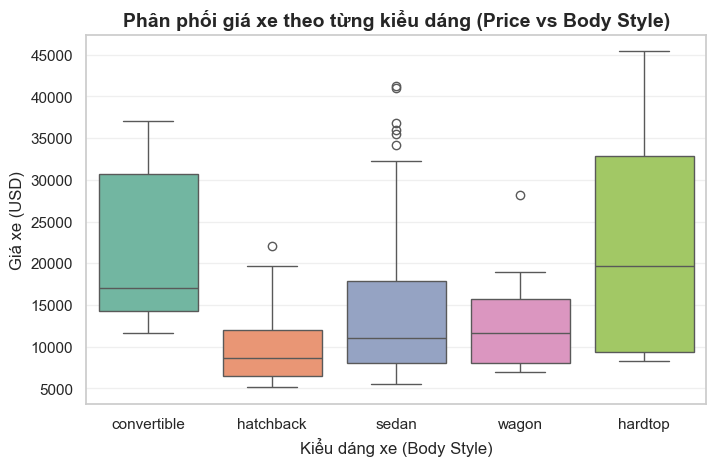

In [76]:
plt.figure(figsize=(8, 4.8))

sns.boxplot(data=df_clean, x='body_style', y='price', hue='body_style', palette='Set2', legend=False)

plt.title('Phân phối giá xe theo từng kiểu dáng (Price vs Body Style)', fontsize=14, fontweight='bold')
plt.xlabel('Kiểu dáng xe (Body Style)', fontsize=12)
plt.ylabel('Giá xe (USD)', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)
plt.show()

**Nhận xét:** Giá trung bình của hardtop và convertible cao hơn tất cả body style còn lại rất nhiều. Còn sedan tuy giá trung bình thấp hơn wagon nhưng gía cao nhất lại hơn wagon.

## M2.4 Engine size liên quan thế nào tới price?

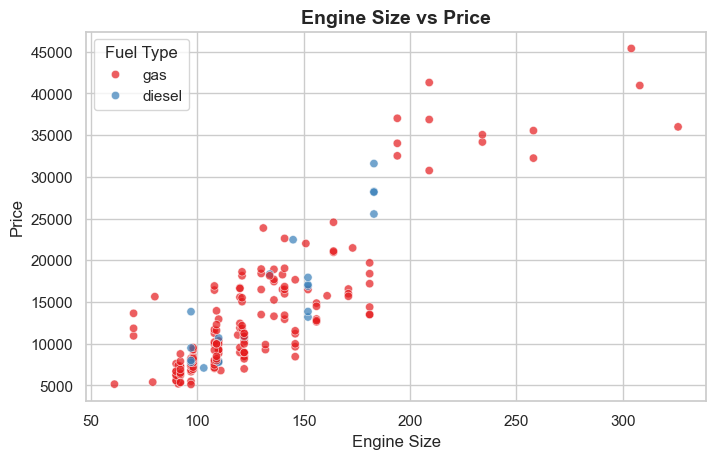

In [77]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
plt.figure(figsize=(8, 4.8))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', palette='Set1', alpha=0.7)
plt.title('Engine Size vs Price', fontsize=14, fontweight='bold')
plt.xlabel('Engine Size', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.grid(True)
plt.legend(title='Fuel Type', loc='upper left')
plt.show()


**Nhận xét:** Động cơ càng lớn thì giá gas càng mắc. Diesel thì chỉ trong tầm giá từ thấp đến trung bình.

## M2.5 Các feature numeric tương quan ra sao?

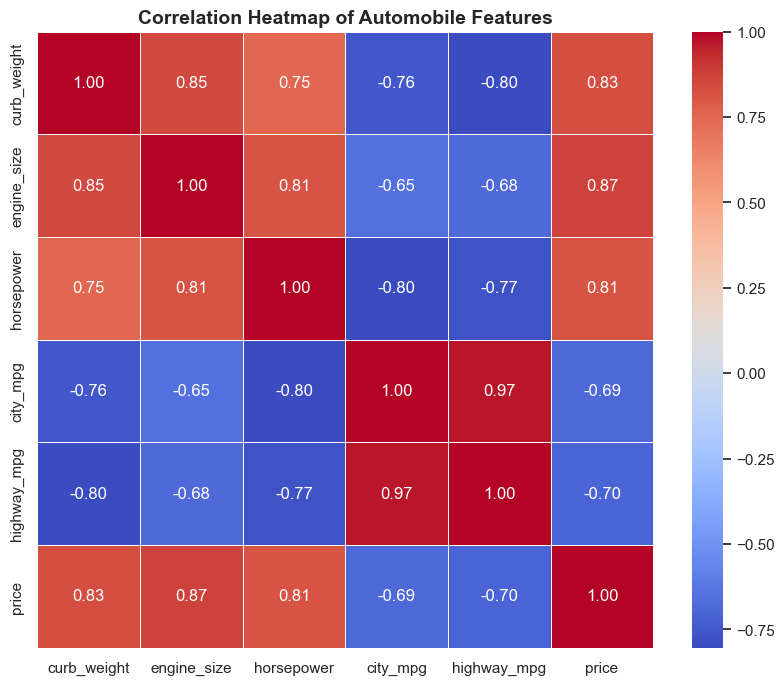

In [78]:
# TODO M2.5: correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean[AUTO_FEATURES].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Automobile Features', fontsize=14, fontweight='bold')
plt.show()

**Nhận xét:** engine_size, curb_weight, price và horsepower có độ tương quan cao với nhau. Ngược lại, chúng lại có độ tương quan nghịch lớn với city_mpg và highway_mpg.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

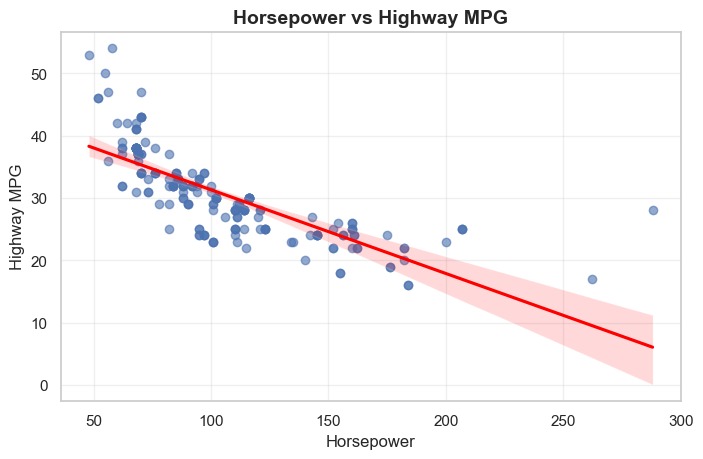

In [79]:
# TODO M2.6: biểu đồ tự chọn
# Horsepower vs Highway MPG
plt.figure(figsize=(8, 4.8))
sns.regplot(data=df_clean, x='horsepower', y='highway_mpg', scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Horsepower vs Highway MPG', fontsize=14, fontweight='bold')
plt.xlabel('Horsepower', fontsize=12)
plt.ylabel('Highway MPG', fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

**Nhận xét:** Horsepower tăng thì highway_mpg có xu hướng giảm, tức xe công suất cao thường tiêu hao nhiên liệu nhiều hơn trên đường cao tốc. 

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

Phát hiện chính:
- Một số ít xe hạng sang có giá trị cực cao (|z| > 2) làm kéo giãn đáng kể dải phân phối giá trị của tập dữ liệu
- Curb_weight có tỷ lệ nghịch so với city_mpg và highway_mpg.
- Mpg trong city và highway có độ tương quan gần như tuyệt đối


Hạn chế của dataset:
- Thiếu hụt nhiều dữ liệu.
- Kích thước mẫu nhỏ nên mean,std,.. nhạy cảm và dễ bị sai lệch.


Ví dụ về correlation không đồng nghĩa causation: engine_size có tương quan cao với price. (động cơ lớn không có nghĩa là xe mắc tiền. Xe mắc tiền là do nhiều yếu tố khác nữa.)


Một câu hỏi nên phân tích tiếp: Nếu thêm data Thương hiệu, nó sẽ tác động đến các yếu tố khác thế nào? (VD: price khi cố định các yếu tố khác.)
